In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [12]:
from scipy.stats import spearmanr

df1 = pd.read_csv("SortedBySensor.csv")    
df2 = pd.read_csv("ExpertCR.csv")

df2_small = df2[["Participant", "Hyperactivity score"]]

sensors = df1["Sensor"].unique()

print("\nCorrelation: Sensors vs Hyperactivity Score\n")

for sensor in sensors:

    # filter one sensor
    sensor_df = df1[df1["Sensor"] == sensor]

    merged = sensor_df.merge(df2_small,
                             on="Participant",
                             how="inner")

    # acceleration
    r_accel, p_accel = spearmanr(
        merged["mean_accel"],
        merged["Hyperactivity score"]
    )
    # jerkiness
    r_jerk, p_jerk = spearmanr(
        merged["mean_jerk"],
        merged["Hyperactivity score"]
    )

    print(f"{sensor}")
    print(f"  Accel: r = {r_accel:.4f}, p = {p_accel:.4f}")
    print(f"  Jerk: r = {r_jerk:.4f}, p = {p_jerk:.4f}")
    print("-" * 40)


Correlation: Sensors vs Hyperactivity Score

AnkleL
  Accel: r = -0.1494, p = 0.6431
  Jerk: r = -0.1248, p = 0.6992
----------------------------------------
AnkleR
  Accel: r = -0.1333, p = 0.6795
  Jerk: r = -0.0667, p = 0.8369
----------------------------------------
Head
  Accel: r = 0.0615, p = 0.8494
  Jerk: r = 0.1142, p = 0.7237
----------------------------------------
Hip
  Accel: r = 0.0299, p = 0.9266
  Jerk: r = -0.0334, p = 0.9179
----------------------------------------
WristL
  Accel: r = 0.1740, p = 0.5886
  Jerk: r = 0.0228, p = 0.9438
----------------------------------------
WristR
  Accel: r = 0.1053, p = 0.7447
  Jerk: r = 0.0667, p = 0.8369
----------------------------------------


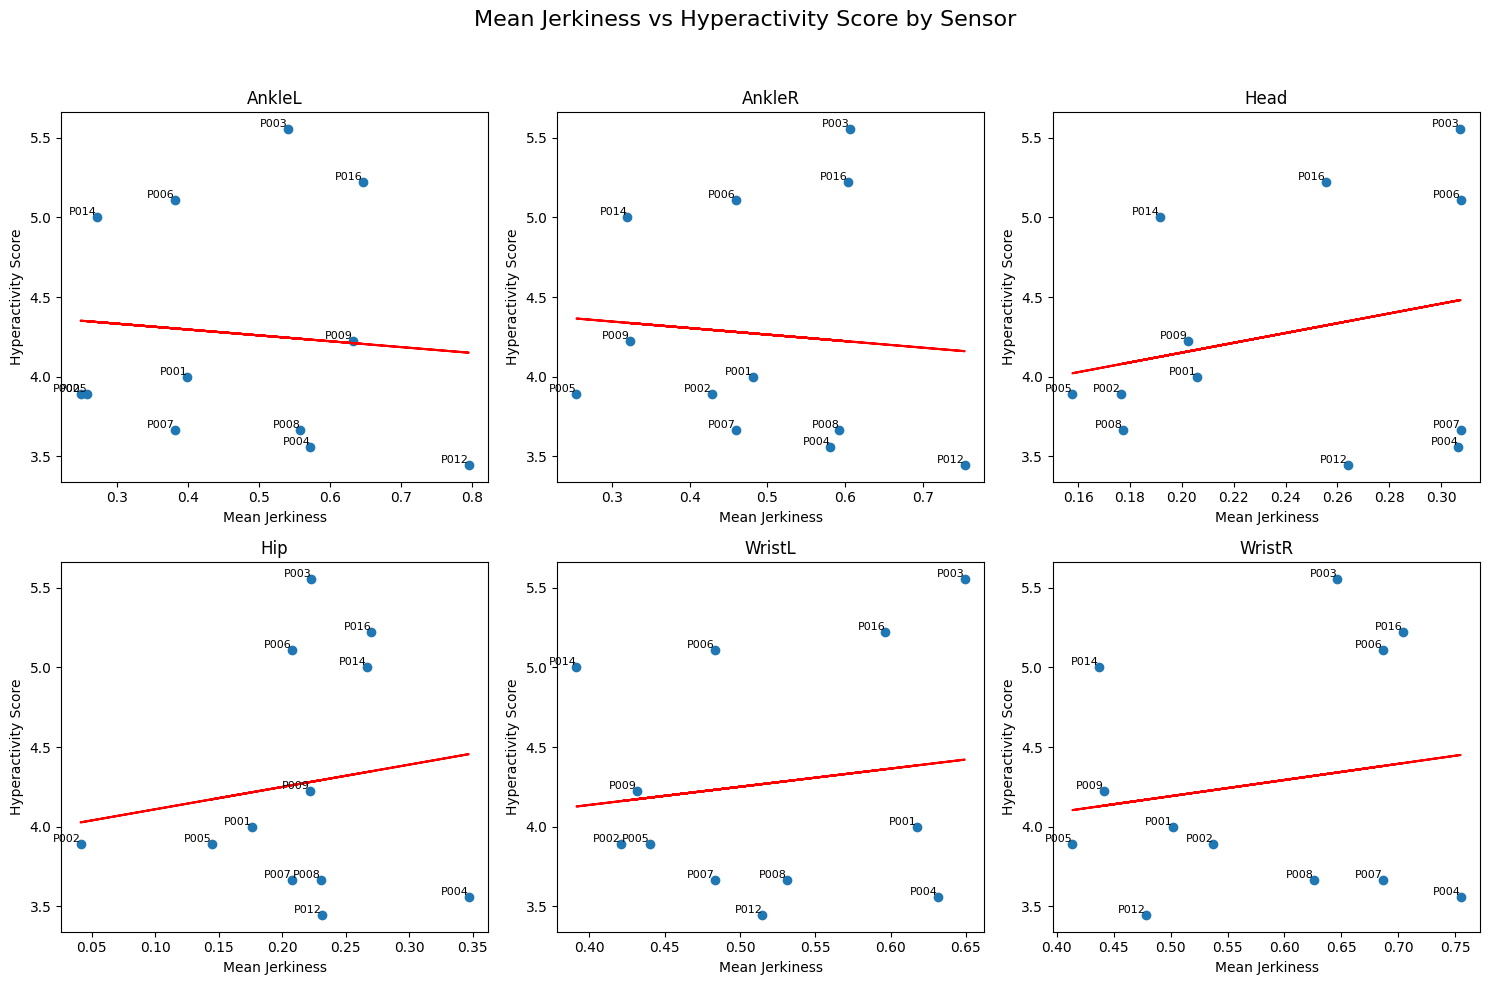

<Figure size 640x480 with 0 Axes>

In [35]:
# mean jerkiness vs hyperactivity 
df1 = pd.read_csv("SortedBySensor.csv")    
df2 = pd.read_csv("ExpertCR.csv")

# keep only needed column
df2_small = df2[["Participant", "Hyperactivity score"]]

# sensors list
sensors = df1["Sensor"].unique()

# grid size
n_sensors = len(sensors)
cols = 3
rows = int(np.ceil(n_sensors / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, sensor in enumerate(sensors):

    # filter sensor
    sensor_df = df1[df1["Sensor"] == sensor]

    # merge
    merged = sensor_df.merge(df2_small, on="Participant", how="inner")

    # drop missing values
    merged = merged.dropna(subset=["mean_jerk", "Hyperactivity score"])

    x = merged["mean_jerk"]
    y = merged["Hyperactivity score"]

    # scatter plot
    axes[i].scatter(x, y)

    # regression line (only if enough points)
    if len(x) > 1:
        m, b = np.polyfit(x, y, 1)
        axes[i].plot(x, m * x + b, color='red')

    # participant labels (FIXED)
    for xi, yi, p in zip(x, y, merged["Participant"]):
        axes[i].text(xi, yi, str(p), fontsize=8, ha='right', va='bottom')

    axes[i].set_xlabel("Mean Jerkiness")
    axes[i].set_ylabel("Hyperactivity Score")
    axes[i].set_title(sensor)

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Mean Jerkiness vs Hyperactivity Score by Sensor", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  
plt.show()
plt.tight_layout()
plt.show()

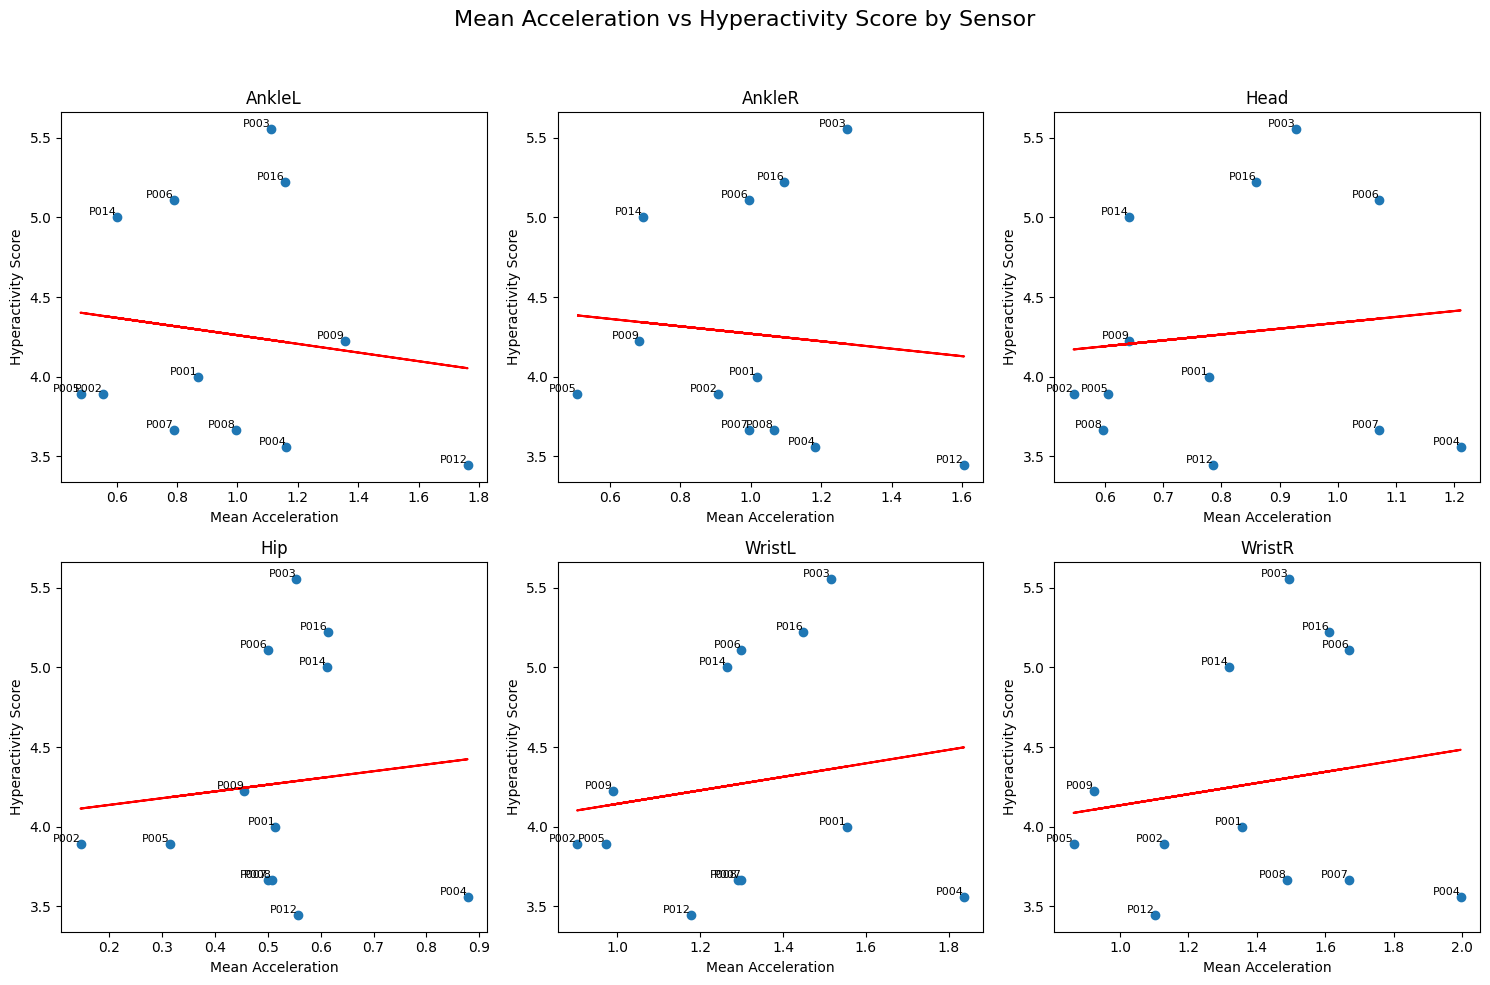

<Figure size 640x480 with 0 Axes>

In [34]:
# mean acceleration vs hyperactivity 
df1 = pd.read_csv("SortedBySensor.csv")    
df2 = pd.read_csv("ExpertCR.csv")

# keep only needed column
df2_small = df2[["Participant", "Hyperactivity score"]]

# sensors list
sensors = df1["Sensor"].unique()

# grid size
n_sensors = len(sensors)
cols = 3
rows = int(np.ceil(n_sensors / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, sensor in enumerate(sensors):

    # filter sensor
    sensor_df = df1[df1["Sensor"] == sensor]

    # merge
    merged = sensor_df.merge(df2_small, on="Participant", how="inner")

    # drop missing values (IMPORTANT)
    merged = merged.dropna(subset=["mean_accel", "Hyperactivity score"])

    x = merged["mean_accel"]
    y = merged["Hyperactivity score"]

    # scatter plot
    axes[i].scatter(x, y)

    # regression line (only if enough points)
    if len(x) > 1:
        m, b = np.polyfit(x, y, 1)
        axes[i].plot(x, m * x + b, color='red')

    # participant labels 
    for xi, yi, p in zip(x, y, merged["Participant"]):
        axes[i].text(xi, yi, str(p), fontsize=8, ha='right', va='bottom')

    axes[i].set_xlabel("Mean Acceleration")
    axes[i].set_ylabel("Hyperactivity Score")
    axes[i].set_title(sensor)

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Mean Acceleration vs Hyperactivity Score by Sensor", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  
plt.show()
plt.tight_layout()
plt.show()

In [23]:
from scipy.stats import spearmanr

df1 = pd.read_csv("SortedBySensor.csv")    
df2 = pd.read_csv("ExpertCR.csv")

df2_small = df2[["Participant", "total avg"]]

sensors = df1["Sensor"].unique()

print("\nCorrelation: Sensors vs Total Avg\n")

for sensor in sensors:

    # filter one sensor
    sensor_df = df1[df1["Sensor"] == sensor]

    merged = sensor_df.merge(df2_small,
                             on="Participant",
                             how="inner")

    # acceleration
    r_accel, p_accel = spearmanr(
        merged["mean_accel"],
        merged["total avg"]
    )
    # jerkiness
    r_jerk, p_jerk = spearmanr(
        merged["mean_jerk"],
        merged["total avg"]
    )

    print(f"{sensor}")
    print(f"  Accel: r = {r_accel:.4f}, p = {p_accel:.4f}")
    print(f"  Jerk: r = {r_jerk:.4f}, p = {p_jerk:.4f}")
    print("-" * 40)


Correlation: Sensors vs Total Avg

AnkleL
  Accel: r = 0.1863, p = 0.5621
  Jerk: r = 0.1090, p = 0.7360
----------------------------------------
AnkleR
  Accel: r = 0.2421, p = 0.4484
  Jerk: r = 0.2421, p = 0.4484
----------------------------------------
Head
  Accel: r = 0.7030, p = 0.0108
  Jerk: r = 0.8049, p = 0.0016
----------------------------------------
Hip
  Accel: r = 0.1582, p = 0.6234
  Jerk: r = 0.0070, p = 0.9827
----------------------------------------
WristL
  Accel: r = 0.6186, p = 0.0320
  Jerk: r = 0.3866, p = 0.2144
----------------------------------------
WristR
  Accel: r = 0.5825, p = 0.0469
  Jerk: r = 0.4982, p = 0.0992
----------------------------------------


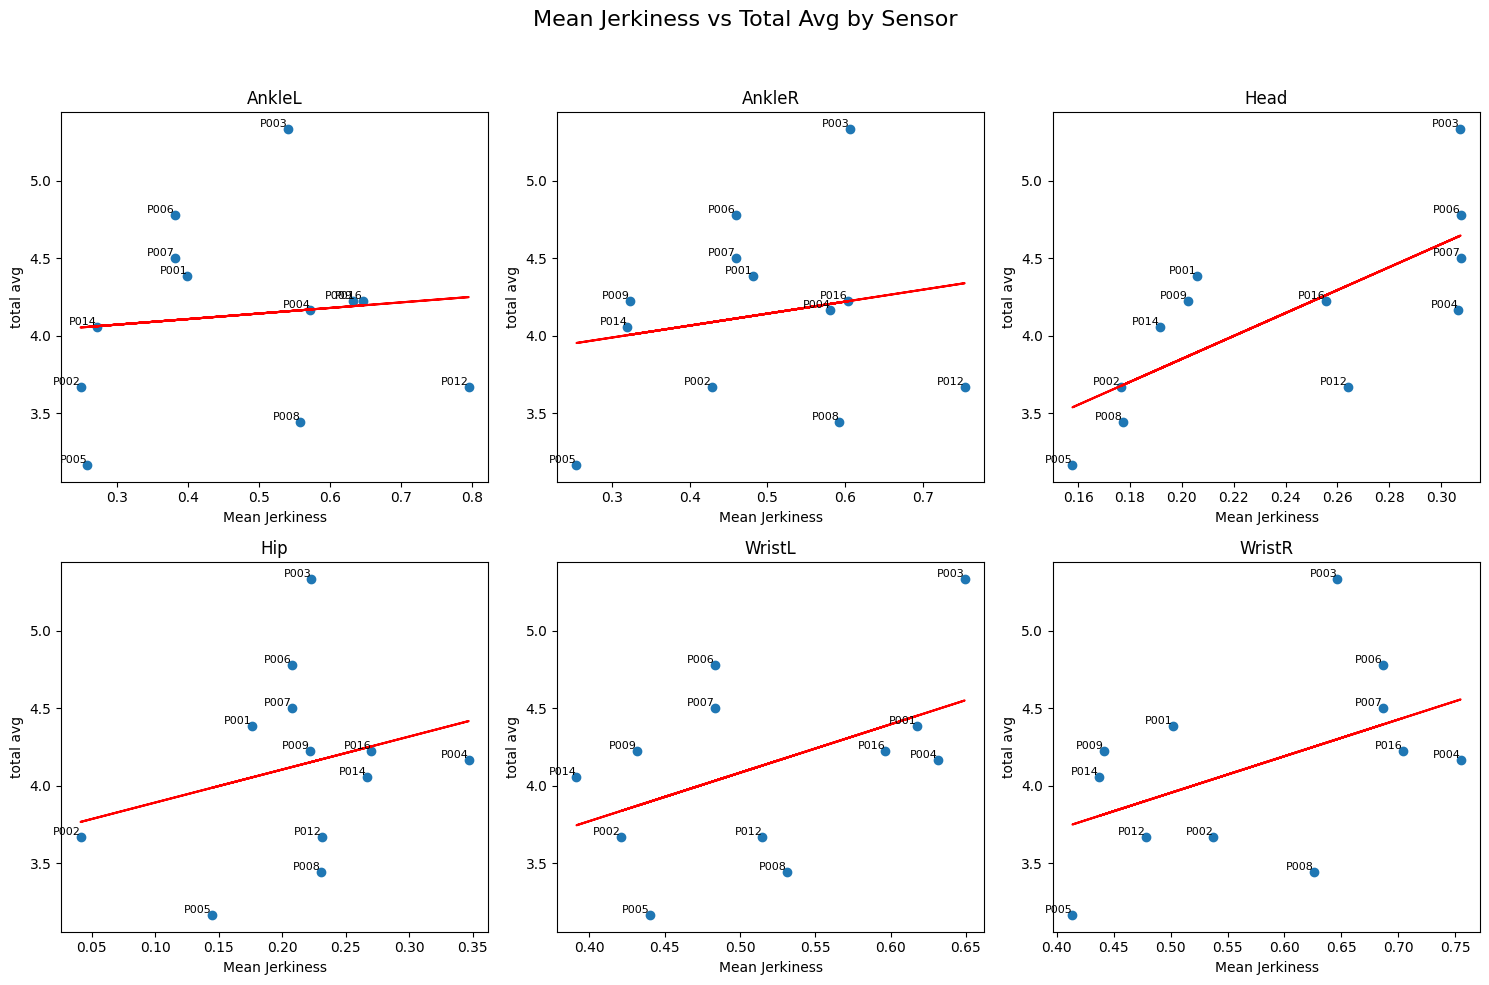

<Figure size 640x480 with 0 Axes>

In [33]:
# Mean jerkiness vs total avg
df1 = pd.read_csv("SortedBySensor.csv")    
df2 = pd.read_csv("ExpertCR.csv")

# keep only needed column
df2_small = df2[["Participant", "total avg"]]

# sensors list
sensors = df1["Sensor"].unique()

# grid size
n_sensors = len(sensors)
cols = 3
rows = int(np.ceil(n_sensors / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, sensor in enumerate(sensors):

    # filter sensor
    sensor_df = df1[df1["Sensor"] == sensor]

    # merge
    merged = sensor_df.merge(df2_small, on="Participant", how="inner")

    # drop missing values 
    merged = merged.dropna(subset=["mean_jerk", "total avg"])

    x = merged["mean_jerk"]
    y = merged["total avg"]

    # scatter plot
    axes[i].scatter(x, y)

    # regression line (only if enough points)
    if len(x) > 1:
        m, b = np.polyfit(x, y, 1)
        axes[i].plot(x, m * x + b, color='red')

    # participant labels 
    for xi, yi, p in zip(x, y, merged["Participant"]):
        axes[i].text(xi, yi, str(p), fontsize=8, ha='right', va='bottom')

    axes[i].set_xlabel("Mean Jerkiness")
    axes[i].set_ylabel("total avg")
    axes[i].set_title(sensor)

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Mean Jerkiness vs Total Avg by Sensor", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  
plt.show()
plt.tight_layout()
plt.show()

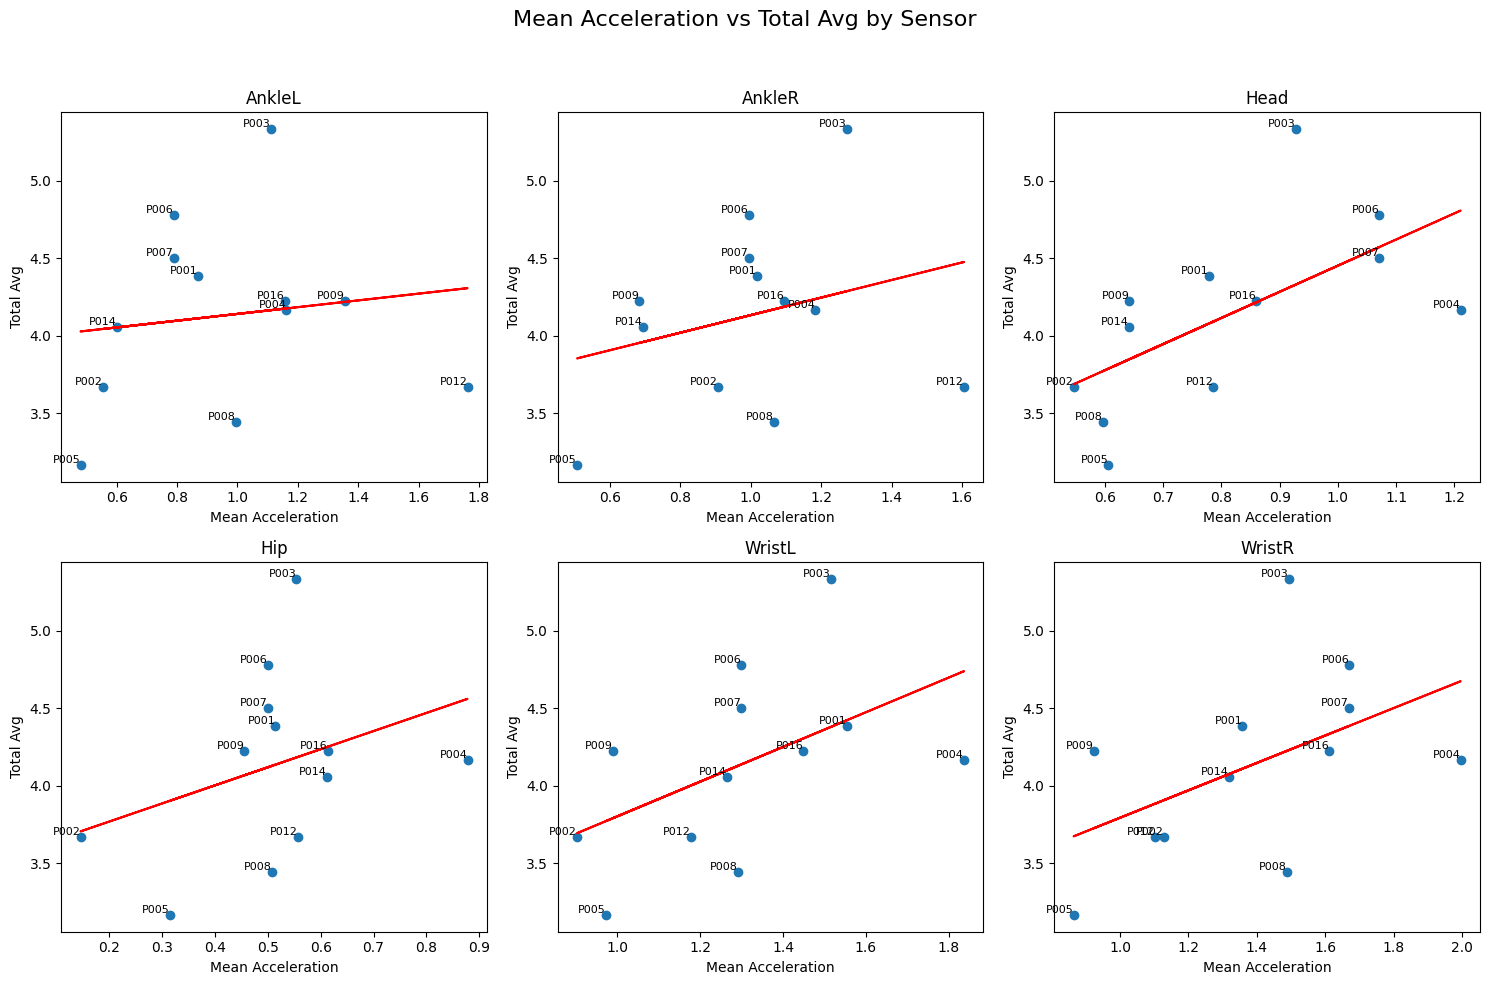

<Figure size 640x480 with 0 Axes>

In [32]:
# mean acceleration vs total avg
df1 = pd.read_csv("SortedBySensor.csv")    
df2 = pd.read_csv("ExpertCR.csv")

# keep only needed column
df2_small = df2[["Participant", "total avg"]]

# sensors list
sensors = df1["Sensor"].unique()

# grid size
n_sensors = len(sensors)
cols = 3
rows = int(np.ceil(n_sensors / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, sensor in enumerate(sensors):

    # filter sensor
    sensor_df = df1[df1["Sensor"] == sensor]

    # merge
    merged = sensor_df.merge(df2_small, on="Participant", how="inner")

    # drop missing values (IMPORTANT)
    merged = merged.dropna(subset=["mean_accel", "total avg"])

    x = merged["mean_accel"]
    y = merged["total avg"]

    # scatter plot
    axes[i].scatter(x, y)

    # regression line (only if enough points)
    if len(x) > 1:
        m, b = np.polyfit(x, y, 1)
        axes[i].plot(x, m * x + b, color='red')

    # participant labels (FIXED)
    for xi, yi, p in zip(x, y, merged["Participant"]):
        axes[i].text(xi, yi, str(p), fontsize=8, ha='right', va='bottom')

    axes[i].set_xlabel("Mean Acceleration")
    axes[i].set_ylabel("Total Avg")
    axes[i].set_title(sensor)

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Mean Acceleration vs Total Avg by Sensor", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  
plt.show()
plt.tight_layout()
plt.show()

In [27]:
from scipy.stats import spearmanr

df1 = pd.read_csv("SortedBySensor.csv")    
df2 = pd.read_csv("ExpertCR.csv")

df2_small = df2[["Participant", "Inattention score"]]

sensors = df1["Sensor"].unique()

print("\nCorrelation: Sensors vs Inattention Score\n")

for sensor in sensors:

    # filter one sensor
    sensor_df = df1[df1["Sensor"] == sensor]

    merged = sensor_df.merge(df2_small,
                             on="Participant",
                             how="inner")

    # acceleration
    r_accel, p_accel = spearmanr(
        merged["mean_accel"],
        merged["Inattention score"]
    )
    # jerkiness
    r_jerk, p_jerk = spearmanr(
        merged["mean_jerk"],
        merged["Inattention score"]
    )

    print(f"{sensor}")
    print(f"  Accel: r = {r_accel:.4f}, p = {p_accel:.4f}")
    print(f"  Jerk: r = {r_jerk:.4f}, p = {p_jerk:.4f}")
    print("-" * 40)


Correlation: Sensors vs Inattention Score

AnkleL
  Accel: r = 0.3163, p = 0.3165
  Jerk: r = 0.1687, p = 0.6002
----------------------------------------
AnkleR
  Accel: r = 0.3930, p = 0.2063
  Jerk: r = 0.3439, p = 0.2738
----------------------------------------
Head
  Accel: r = 0.7100, p = 0.0097
  Jerk: r = 0.7909, p = 0.0022
----------------------------------------
Hip
  Accel: r = 0.0914, p = 0.7776
  Jerk: r = -0.0562, p = 0.8622
----------------------------------------
WristL
  Accel: r = 0.6046, p = 0.0373
  Jerk: r = 0.5132, p = 0.0879
----------------------------------------
WristR
  Accel: r = 0.5544, p = 0.0614
  Jerk: r = 0.5158, p = 0.0861
----------------------------------------


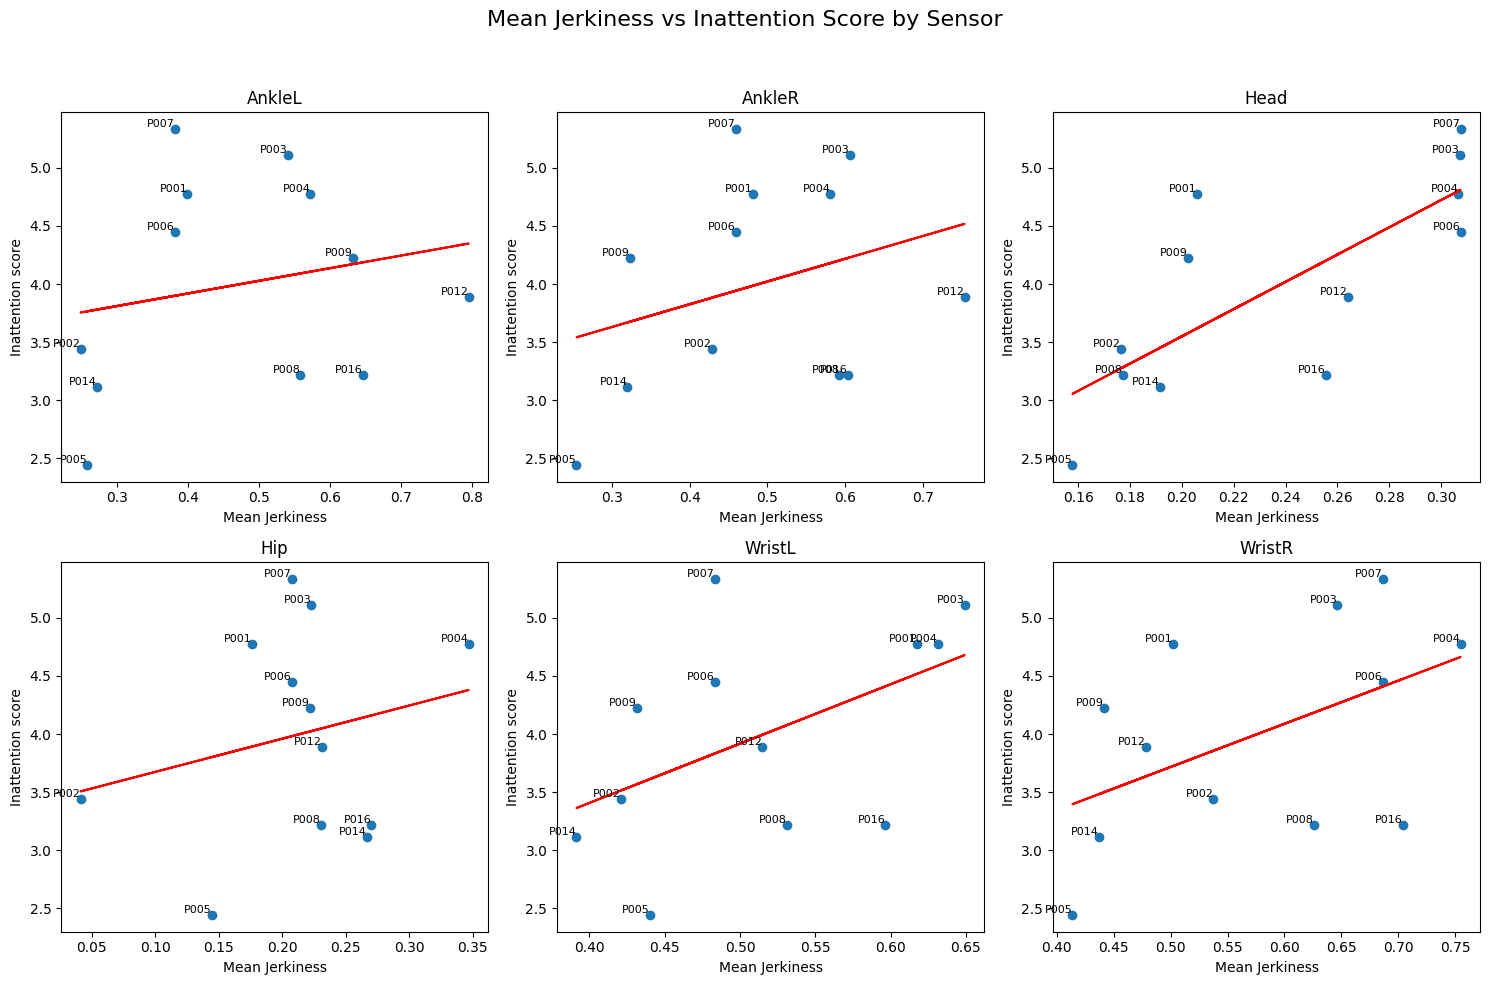

<Figure size 640x480 with 0 Axes>

In [31]:
# mean jerkiness vs inattention score
df1 = pd.read_csv("SortedBySensor.csv")    
df2 = pd.read_csv("ExpertCR.csv")

# keep only needed column
df2_small = df2[["Participant", "Inattention score"]]

# sensors list
sensors = df1["Sensor"].unique()

# grid size
n_sensors = len(sensors)
cols = 3
rows = int(np.ceil(n_sensors / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, sensor in enumerate(sensors):

    # filter sensor
    sensor_df = df1[df1["Sensor"] == sensor]

    # merge
    merged = sensor_df.merge(df2_small, on="Participant", how="inner")

    # drop missing values 
    merged = merged.dropna(subset=["mean_jerk", "Inattention score"])

    x = merged["mean_jerk"]
    y = merged["Inattention score"]

    # scatter plot
    axes[i].scatter(x, y)

    # regression line (only if enough points)
    if len(x) > 1:
        m, b = np.polyfit(x, y, 1)
        axes[i].plot(x, m * x + b, color='red')

    # participant labels 
    for xi, yi, p in zip(x, y, merged["Participant"]):
        axes[i].text(xi, yi, str(p), fontsize=8, ha='right', va='bottom')

    axes[i].set_xlabel("Mean Jerkiness")
    axes[i].set_ylabel("Inattention score")
    axes[i].set_title(sensor)

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Mean Jerkiness vs Inattention Score by Sensor", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  
plt.show()
plt.tight_layout()
plt.show()

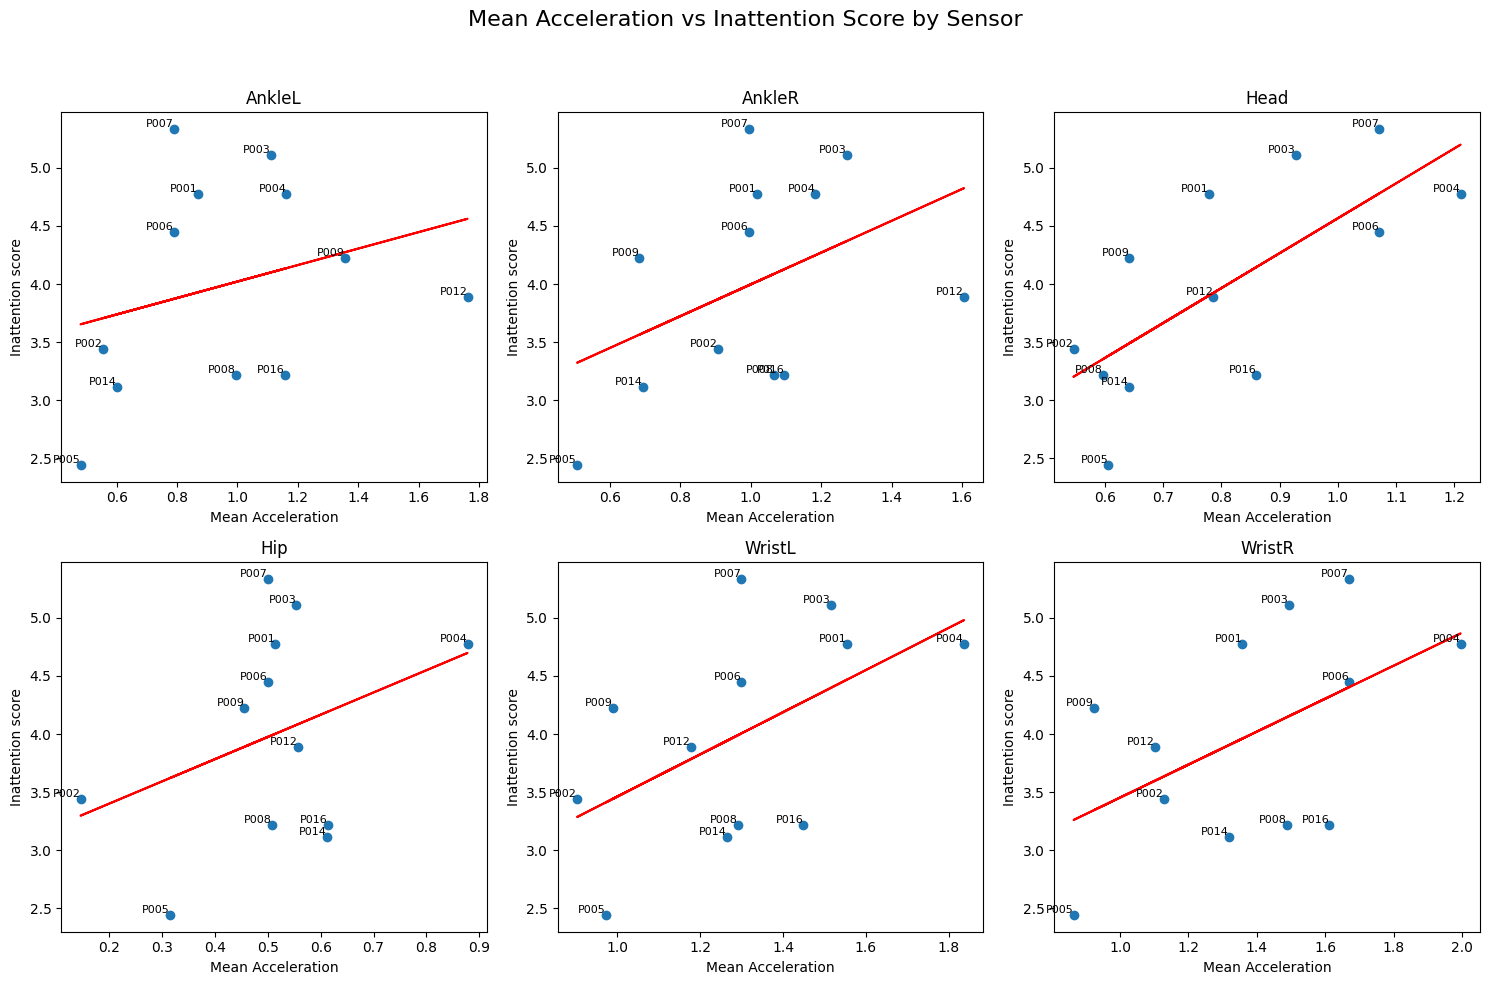

<Figure size 640x480 with 0 Axes>

In [30]:
# mean acceleration vs inattention score
df1 = pd.read_csv("SortedBySensor.csv")    
df2 = pd.read_csv("ExpertCR.csv")

# keep only needed column
df2_small = df2[["Participant", "Inattention score"]]

# sensors list
sensors = df1["Sensor"].unique()

# grid size
n_sensors = len(sensors)
cols = 3
rows = int(np.ceil(n_sensors / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, sensor in enumerate(sensors):

    # filter sensor
    sensor_df = df1[df1["Sensor"] == sensor]

    # merge
    merged = sensor_df.merge(df2_small, on="Participant", how="inner")

    # drop missing values 
    merged = merged.dropna(subset=["mean_accel", "Inattention score"])

    x = merged["mean_accel"]
    y = merged["Inattention score"]

    # scatter plot
    axes[i].scatter(x, y)

    # regression line 
    if len(x) > 1:
        m, b = np.polyfit(x, y, 1)
        axes[i].plot(x, m * x + b, color='red')

    # participant labels 
    for xi, yi, p in zip(x, y, merged["Participant"]):
        axes[i].text(xi, yi, str(p), fontsize=8, ha='right', va='bottom')

    axes[i].set_xlabel("Mean Acceleration")
    axes[i].set_ylabel("Inattention score")
    axes[i].set_title(sensor)

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Mean Acceleration vs Inattention Score by Sensor", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  
plt.show()
plt.tight_layout()
plt.show()